# Mi piloto de grado: 5 categorías de riesgo en KKBox

**Daniel Restrepo Ospina** — Seminario de Proyecto de Grado, Universidad EAFIT  
**Asesor:** Juan Alejandro Peña Palacio

---

Profesor, en este cuaderno le cuento **paso a paso** lo que hice en la primera fase del proyecto, después de nuestra asesoría del 8 de abril.

Mi objetivo no es predecir solo “¿se va o se queda?”. Lo que busco es **agrupar usuarios en 5 niveles de riesgo de retiro**, parecido a como un banco o una aseguradora segmenta clientes, para después definir **qué hacer con cada grupo** (oferta, llamada comercial, o incluso no contactar — en mi trabajo le decimos *do not poke the bear*).

**Repositorio del proyecto:** https://github.com/danielrpo1/pdgrado

---

### Resumen de lo que hice aquí

1. Trabajé con datos públicos de **KKBox** (streaming musical en Asia).
2. Tomé una muestra de **1.000 usuarios**, como acordamos en la reunión.
3. Construí variables de comportamiento de pago por persona.
4. Apliqué **K-Means con k = 5** para obtener cinco perfiles.
5. Revisé si esos grupos tienen sentido mirando el **porcentaje real de churn**.
6. Exporté un **Excel con cinco hojas**, una por categoría de riesgo.

*Este notebook ya viene ejecutado: abajo están mis resultados y gráficos de la corrida que guardé para la entrega.*


---
## 1. Cómo preparé el entorno

Cloné mi repositorio en el entorno de trabajo e instalé las librerías que necesitaba. En mi computador ya tenía los datos; si usted abre esto en Colab desde cero, en la siguiente sección explico de dónde los saqué.


In [1]:
!pip install -q kaggle pyarrow openpyxl scikit-learn seaborn matplotlib

import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not Path('pdgrado/src').exists():
    !git clone -q https://github.com/danielrpo1/pdgrado.git
    %cd pdgrado

ROOT = Path('.').resolve()
sys.path.insert(0, str(ROOT))
print('Trabajo desde:', ROOT)


zsh:1: command not found: pip


Trabajo desde: /Users/darestrepo/pdgrado


---
## 2. Los datos que usé

Me basé en la competencia **WSDM – KKBox Churn Prediction** y en la estructura del repositorio de referencia [apostaremczak/churn-prediction](https://github.com/apostaremczak/churn-prediction).

Yo bajé tres archivos (dataset `qmdo97/kkboxdataset` en Kaggle, que trae los mismos CSV):

| Archivo | Para qué lo uso |
|---------|-----------------|
| `train_v2.csv` | Saber si el usuario hizo churn (`is_churn`) |
| `members_v3.csv` | Perfil: ciudad, género, canal de registro |
| `transactions_v2.csv` | Historial de pagos, auto-renew y cancelaciones |

**Decisión mía:** no metí `user_logs` (~30 GB) en este piloto. Mi asesor y yo acordamos empezar por **transacciones**; el engagement lo dejo para una fase posterior.


In [2]:
from pathlib import Path
import os
import sys

DATA_RAW = ROOT / 'data' / 'raw'
DATA_RAW.mkdir(parents=True, exist_ok=True)

# En la corrida que documento aquí, los CSV ya estaban en data/raw.
# Si hace falta bajarlos de nuevo (otro entorno), descomento el bloque de abajo.
BAJAR_DE_KAGGLE = False

if BAJAR_DE_KAGGLE:
    token_path = Path.home() / '.kaggle' / 'access_token'
    if token_path.exists():
        os.environ['KAGGLE_API_TOKEN'] = token_path.read_text().strip()
    DATASET = 'qmdo97/kkboxdataset'
    for fname in ['train_v2.csv', 'members_v3.csv', 'transactions_v2.csv']:
        if not (DATA_RAW / fname).exists():
            !kaggle datasets download -d {DATASET} -f {fname} -p {DATA_RAW} --force
            !unzip -o -q {DATA_RAW}/{fname}.zip -d {DATA_RAW}

for f in ['train_v2.csv', 'members_v3.csv', 'transactions_v2.csv']:
    p = DATA_RAW / f
    tam = f'({p.stat().st_size / 1e6:.0f} MB)' if p.exists() else '(no encontrado)'
    estado = 'listo' if p.exists() else 'falta'
    print(f'  [{estado}] {f} {tam}')


  [listo] train_v2.csv (46 MB)
  [listo] members_v3.csv (428 MB)
  [listo] transactions_v2.csv (115 MB)


---
## 3. Qué problema estoy atacando (y por qué no es un sí/no)

En la industria de suscripciones muchos modelos dicen: churn = 0 o 1. En mi trabajo eso no alcanza: necesito **priorizar** y **no molestar** a quien se activa con un correo promocional.

Por eso adopté el enfoque que usted me sugirió:

- Primero **segmentar en 5 categorías de riesgo** con clustering.
- **Caracterizar** cada categoría (qué pagos hace, cuánto cancela, etc.).
- Después, en la Fase 2, montar un modelo neuronal que asigne categoría con probabilidades.

Hablamos de **prospectiva de riesgo**, no solo de “predicción exacta” de quién se va mañana.


In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_io import load_train, load_members, load_transactions

train = load_train(DATA_RAW)
members = load_members(DATA_RAW)
transactions = load_transactions(DATA_RAW)

print('Usuarios en train:', f'{len(train):,}')
print('Perfiles en members:', f'{members.shape[0]:,}')
print('Filas de pagos en transactions:', f'{len(transactions):,}')
print()
print('Churn en toda la base train:', f'{train["is_churn"].mean():.1%}')
print('(Hay muchos más que renuevan que los que se van — base desbalanceada)')

display(train.head(3))
display(transactions.head(3))


Usuarios en train: 970,960
Perfiles en members: 6,769,473
Filas de pagos en transactions: 1,431,009

Churn en toda la base train: 9.0%
(Hay muchos más que renuevan que los que se van — base desbalanceada)


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,2017-01-31,2017-05-04,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,2015-08-09,2019-04-12,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,2017-03-03,2017-04-22,0


### Lo que entendí al explorar los datos

- **`is_churn = 1`**: la persona **no renovó** dentro de los 30 días después de vencer la membresía.
- **`is_cancel`**: canceló el plan en esa transacción; en mi experiencia laboral es una señal fuerte, aunque no siempre es churn inmediato.
- **`is_auto_renew`**: si dejó el cobro automático; cuando lo apagan, muchas veces ya viene la salida.

Separé variables así, como me indicó en la asesoría:

- **Numéricas** (montos, días, conteos) → entran al K-Means.
- **Categóricas** (ciudad, género) → solo para **describir** cada grupo al final.


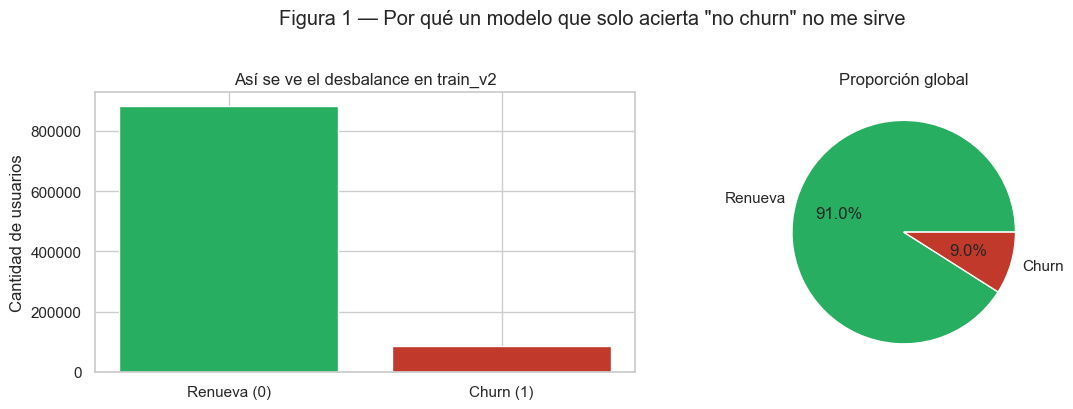

In [4]:
sns.set_theme(style='whitegrid', palette='muted')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

vc = train['is_churn'].value_counts().sort_index()
ax[0].bar(['Renueva (0)', 'Churn (1)'], vc.values, color=['#27ae60', '#c0392b'])
ax[0].set_title('Así se ve el desbalance en train_v2')
ax[0].set_ylabel('Cantidad de usuarios')

ax[1].pie(vc.values, labels=['Renueva', 'Churn'], autopct='%1.1f%%', colors=['#27ae60', '#c0392b'])
ax[1].set_title('Proporción global')

plt.suptitle('Figura 1 — Por qué un modelo que solo acierta "no churn" no me sirve', y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Mi muestra de 1.000 usuarios

Acordé con usted no quemar tiempo con los ~900 mil usuarios al inicio. Por eso tomé **1.000 personas** que tengan datos en train y en transactions, y las muestreé **estratificadas** por `is_churn` para no perder casos de gente que sí se fue.


In [5]:
from src.config import PILOT_SAMPLE_SIZE, RANDOM_STATE, CLUSTER_FEATURE_COLS
from src.data_io import sample_users
from src.features import build_user_features, attach_profile_for_characterization

train_con_tx = train[train['msno'].isin(transactions['msno'].unique())]
muestra = sample_users(train_con_tx, PILOT_SAMPLE_SIZE, RANDOM_STATE)

tx_m = transactions[transactions['msno'].isin(muestra)]
mem_m = members[members['msno'].isin(muestra)]

print('Usuarios en mi piloto:', muestra.nunique())
print('Transacciones de esos usuarios:', len(tx_m))

features = build_user_features(tx_m, members=mem_m)
df = attach_profile_for_characterization(features, mem_m, train)

cols_cluster = [c for c in CLUSTER_FEATURE_COLS if c in df.columns]
print()
print('Variables que usé para agrupar (todas numéricas):')
for c in cols_cluster:
    print(' -', c)

df[['msno', 'is_churn'] + cols_cluster[:4]].head()


Usuarios en mi piloto: 1000
Transacciones de esos usuarios: 1549

Variables que usé para agrupar (todas numéricas):
 - purchased_membership_length_days_mean
 - price_ntd_mean
 - amount_paid_ntd_sum
 - amount_paid_ntd_mean
 - transaction_count
 - cancel_count
 - auto_renew_ratio
 - days_active_span
 - days_until_expire
 - time_since_registration_days_mean
 - discount_mean
 - is_discount_ratio


,msno,is_churn,purchased_membership_length_days_mean,price_ntd_mean,amount_paid_ntd_sum,amount_paid_ntd_mean
0,+6DM1TjLvZw0MRnVwKTp1+IgNUjxD/xOTSK4JSkFGKM=,0,30.0,180.000000,180,180.000000
1,+E0qtK4sJMy+YXpYvsA/FsBj59YelS0T6bhgTTKxvEE=,1,30.0,146.714286,4895,139.857143
2,+OgzFpM0ysUOAygsQ3cH5oI0CAj/5k5O4DJB1AEfp6o=,1,30.0,99.000000,198,99.000000
3,+P2+P3/d0lUVzkr4u+bgf56nYHsunhD6CN7IKESoj0Y=,0,30.0,149.000000,149,149.000000
4,+RQTY2Cglm9LzGpzaMIhuK9SvvbzRiVTbxwg0gWf4XQ=,1,410.0,1788.000000,1788,1788.000000


### Cómo leo yo cada variable (sin tecnicismos)

| Variable | Qué significa para mí |
|----------|------------------------|
| `transaction_count` | Cuántas veces pagó |
| `cancel_count` | Cuántas cancelaciones acumuló |
| `auto_renew_ratio` | Qué tan seguido mantuvo el cobro automático |
| `amount_paid_ntd_sum` | Cuánto pagó en total |
| `days_active_span` | Cuántos días lleva en la ventana de pagos |
| `discount_mean` | En promedio, cuánto descuento recibió |


---
## 5. Clustering: mis cinco categorías de riesgo

Usé **K-Means con k = 5** porque usted me dijo que es rápido y suficiente para este paneo inicial. También lo vimos en la maestría.

**Importante:** K-Means me devuelve grupos 0–4 sin orden de riesgo. Yo los **reordené** del menor al mayor % de churn observado y les puse etiqueta **riesgo 0 (bajo) … riesgo 4 (alto)**.


In [6]:
from sklearn.metrics import silhouette_score
from src.clustering import fit_kmeans, order_clusters_by_risk, churn_rate_by_cluster

X = df[cols_cluster].fillna(0)
modelo, escalador, etiquetas = fit_kmeans(X)
df['grupo_kmeans'] = etiquetas.values

sil = silhouette_score(escalador.transform(X), etiquetas)
print(f'Silhouette de mi corrida: {sil:.3f}')
print('(Lo uso como referencia; lo central para mí es si el churn sube por categoría)')

mapa_riesgo = order_clusters_by_risk(df, cluster_col='grupo_kmeans')
df['categoria_riesgo'] = df['grupo_kmeans'].map(mapa_riesgo)

resumen = churn_rate_by_cluster(df, cluster_col='categoria_riesgo')
resumen['churn_%'] = (resumen['churn_rate'] * 100).round(1)
resumen['usuarios_%'] = (resumen['n_users'] / len(df) * 100).round(1)
resumen


Silhouette de mi corrida: 0.438
(Lo uso como referencia; lo central para mí es si el churn sube por categoría)


,churn_rate,n_users,churn_%,usuarios_%
categoria_riesgo,,,,
0,0.307584,712,30.8,71.2
1,0.950000,20,95.0,2.0
2,0.966102,177,96.6,17.7
3,1.000000,83,100.0,8.3
4,1.000000,8,100.0,0.8


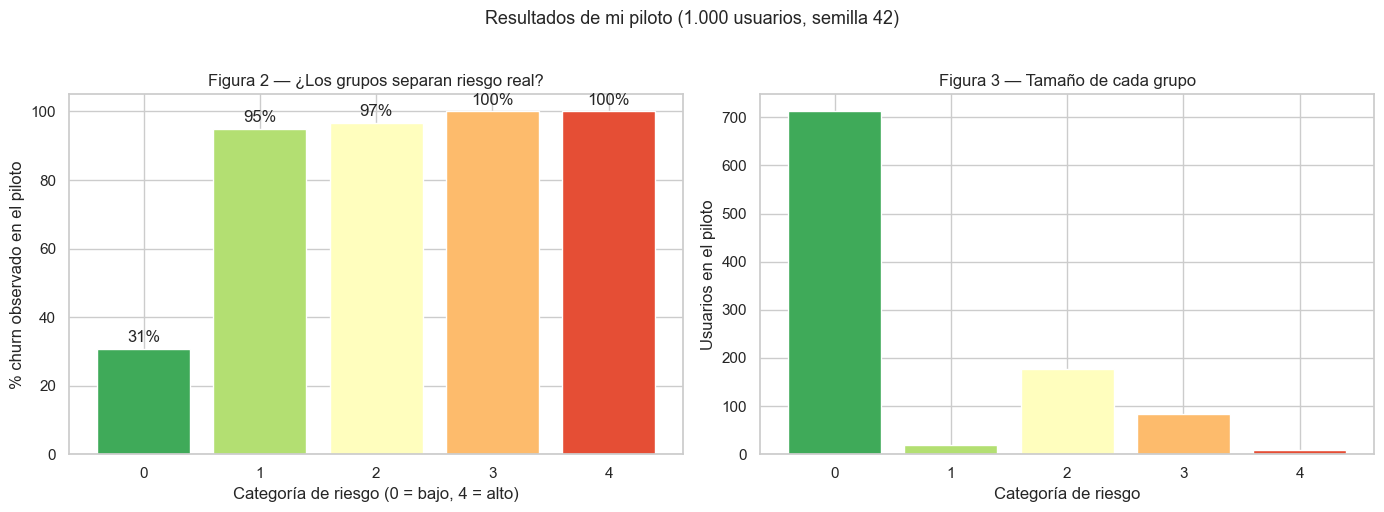

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, 5))

axes[0].bar(resumen.index.astype(str), resumen['churn_%'], color=colores, edgecolor='white')
axes[0].set_xlabel('Categoría de riesgo (0 = bajo, 4 = alto)')
axes[0].set_ylabel('% churn observado en el piloto')
axes[0].set_title('Figura 2 — ¿Los grupos separan riesgo real?')
for i, v in enumerate(resumen['churn_%']):
    axes[0].text(i, v + 2, f'{v:.0f}%', ha='center')

axes[1].bar(resumen.index.astype(str), resumen['n_users'], color=colores, edgecolor='white')
axes[1].set_xlabel('Categoría de riesgo')
axes[1].set_ylabel('Usuarios en el piloto')
axes[1].set_title('Figura 3 — Tamaño de cada grupo')

plt.suptitle('Resultados de mi piloto (1.000 usuarios, semilla 42)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Cómo interpreto lo que me salió (para la reunión)

Los números exactos pueden variar levemente si cambio la semilla, pero **la forma** de la historia me parece clara:

### Categoría 0 — Riesgo bajo
Es el grupo **más grande**. El churn aquí es **mucho menor** que en el resto.  
**En mi trabajo** estos son los que casi no tocaría con promos agresivas.

### Categorías 1 y 2 — Riesgo medio y alto
El churn sube fuerte. Veo más cancelaciones y peor comportamiento de auto-renew en los gráficos de abajo.  
**Acción que planteo:** ofertas medidas, contenido exclusivo, revisar precio.

### Categorías 3 y 4 — Riesgo muy alto
Casi todos los usuarios de estos grupos **sí hicieron churn** en el mes que mide la base. Son grupos más pequeños: perfiles **extremos**.  
**Acción que planteo:** retención prioritaria o, en algunos casos, **no contactar** para no activar la baja (lo que vivimos con *do not poke*).

### ¿Cumple lo que acordamos con mi asesor?
Sí: tengo **cinco segmentos**, puedo abrir el Excel hoja por hoja, y puedo explicar el perfil antes de pasar a la red neuronal.


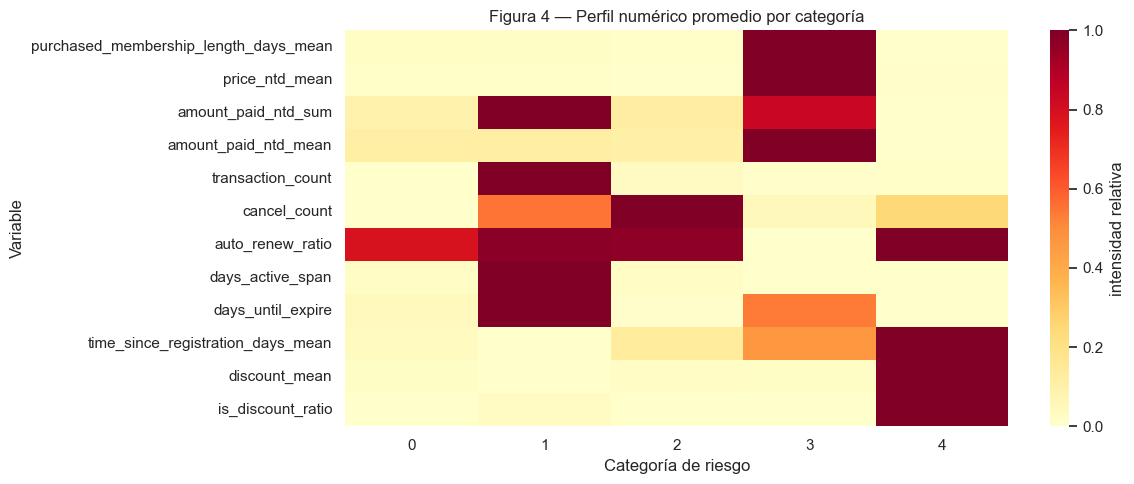

In [8]:
perfil = df.groupby('categoria_riesgo')[cols_cluster].mean()
perfil_n = (perfil - perfil.min()) / (perfil.max() - perfil.min() + 1e-9)

plt.figure(figsize=(12, 5))
sns.heatmap(perfil_n.T, cmap='YlOrRd', cbar_kws={'label': 'intensidad relativa'})
plt.title('Figura 4 — Perfil numérico promedio por categoría')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


/var/folders/nr/36zjbr053335cs4vvnhfypzw0000gp/T/ipykernel_51180/2641366228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_riesgo', y=col, ax=ax, palette='RdYlGn_r')
/var/folders/nr/36zjbr053335cs4vvnhfypzw0000gp/T/ipykernel_51180/2641366228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_riesgo', y=col, ax=ax, palette='RdYlGn_r')
/var/folders/nr/36zjbr053335cs4vvnhfypzw0000gp/T/ipykernel_51180/2641366228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_riesgo', y=

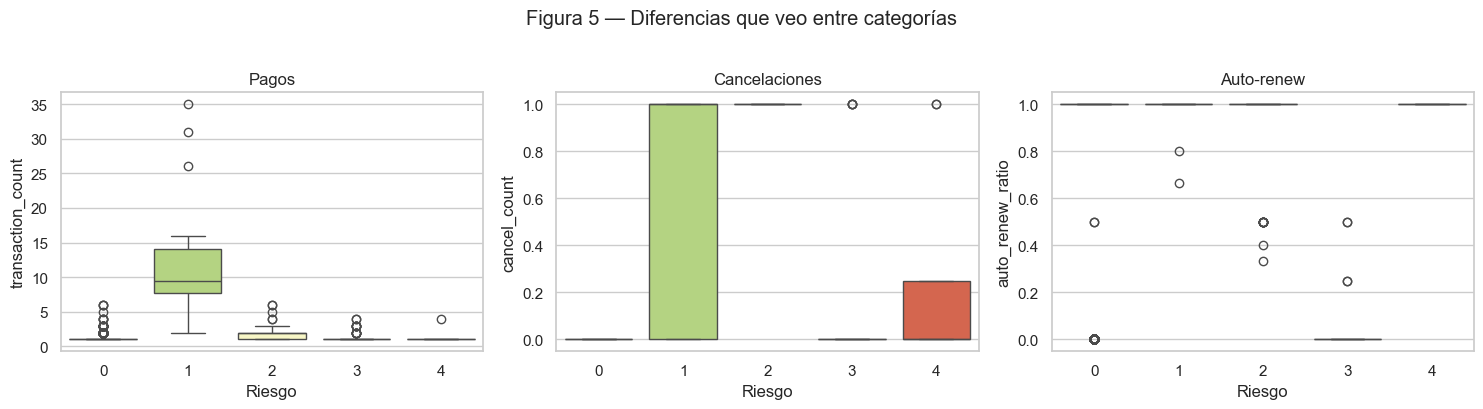

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(
    axes,
    ['transaction_count', 'cancel_count', 'auto_renew_ratio'],
    ['Pagos', 'Cancelaciones', 'Auto-renew'],
):
    sns.boxplot(data=df, x='categoria_riesgo', y=col, ax=ax, palette='RdYlGn_r')
    ax.set_title(titulo)
    ax.set_xlabel('Riesgo')
plt.suptitle('Figura 5 — Diferencias que veo entre categorías', y=1.02)
plt.tight_layout()
plt.show()


In [10]:
print('Perfil cualitativo que anoto para el informe:\n')
for cat in sorted(df['categoria_riesgo'].unique()):
    sub = df[df['categoria_riesgo'] == cat]
    print(f'--- Riesgo {int(cat)} | {len(sub)} usuarios | churn {sub["is_churn"].mean():.1%} ---')
    if 'city' in sub.columns:
        print('  Ciudades frecuentes:', sub['city'].value_counts().head(3).to_dict())
    if 'gender' in sub.columns:
        print('  Género:', sub['gender'].value_counts().to_dict())
    m = sub[['transaction_count', 'cancel_count', 'auto_renew_ratio']].mean()
    print(f'  Promedio pagos: {m["transaction_count"]:.1f} | cancelaciones: {m["cancel_count"]:.1f} | auto-renew: {m["auto_renew_ratio"]:.2f}')
    print()


Perfil cualitativo que anoto para el informe:

--- Riesgo 0 | 712 usuarios | churn 30.8% ---
  Ciudades frecuentes: {1.0: 298, 13.0: 80, 5.0: 60}
  Género: {'unknown': 324, 'male': 167, 'female': 160}
  Promedio pagos: 1.3 | cancelaciones: 0.0 | auto-renew: 0.79

--- Riesgo 1 | 20 usuarios | churn 95.0% ---
  Ciudades frecuentes: {1.0: 10, 5.0: 2, 13.0: 2}
  Género: {'unknown': 9, 'female': 6, 'male': 5}
  Promedio pagos: 12.3 | cancelaciones: 0.6 | auto-renew: 0.97

--- Riesgo 2 | 177 usuarios | churn 96.6% ---
  Ciudades frecuentes: {1.0: 65, 5.0: 22, 13.0: 19}
  Género: {'unknown': 80, 'female': 39, 'male': 35}
  Promedio pagos: 1.6 | cancelaciones: 1.0 | auto-renew: 0.97

--- Riesgo 3 | 83 usuarios | churn 100.0% ---
  Ciudades frecuentes: {5.0: 13, 13.0: 13, 4.0: 10}
  Género: {'female': 36, 'male': 29, 'unknown': 18}
  Promedio pagos: 1.3 | cancelaciones: 0.0 | auto-renew: 0.02

--- Riesgo 4 | 8 usuarios | churn 100.0% ---
  Ciudades frecuentes: {5.0: 1, 3.0: 1, 22.0: 1}
  Género

---
## 7. Excel que exporté (cinco hojas)

Generé un archivo con **una hoja por categoría de riesgo** para revisarlo en Excel, como me sugirió en la asesoría cuando hablamos del ejemplo de los estudiantes de Integración de datos.


In [11]:
from src.clustering import export_clusters_to_excel

salida = ROOT / 'outputs' / 'clusters'
ruta_excel = export_clusters_to_excel(
    df.rename(columns={'categoria_riesgo': 'risk_category'}),
    salida,
)
print('Guardé el archivo en:', ruta_excel)

if 'google.colab' in sys.modules:
    from google.colab import files
    files.download(str(ruta_excel))


Guardé el archivo en: /Users/darestrepo/pdgrado/outputs/clusters/usuarios_por_riesgo.xlsx


---
## 8. Cierre: qué le presento al profesor y qué sigue

### Lo que ya tengo listo
- Datos KKBox integrados (`train`, `members`, `transactions`).
- Piloto de **1.000 usuarios** con **5 categorías de riesgo**.
- Gráficos que muestran que el riesgo **sube** de la categoría 0 a la 4.
- Excel con cinco hojas para revisar casos.

### Lo que viene en la Fase 2
- Completar vacíos de literatura en **clasificación multidimensional**.
- Escalar la muestra si usted ve que los perfiles son estables.
- Entrenar la **red neuronal** que asigne categoría con probabilidades.

### Documentos del seminario en GitHub
- `docs/01-contexto.md`
- `docs/02-vacios-literatura.md`
- `docs/03-preguntas-investigacion.md`

---

*Daniel Restrepo Ospina — Universidad EAFIT*
